In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!pip install pdf2image

In [ ]:
# Install poppler (required for converting PDFs)
!apt-get install -y poppler-utils

In [ ]:
from pdf2image import convert_from_path
import os
import shutil
from google.colab import drive

# --- Step 1: Mount Google Drive ---
drive.mount('/content/drive', force_remount=True)

# --- Step 2: Convert PDFs to TIFF and save directly in Drive ---
def pdf_to_tiff(pdf_path, drive_output_root, input_root, dpi=300):
    os.makedirs(drive_output_root, exist_ok=True)
    images = convert_from_path(pdf_path, dpi=dpi)
    saved_files = []

    # Make filename unique using relative path
    rel_path = os.path.relpath(pdf_path, input_root)
    rel_path_safe = rel_path.replace(os.sep, "_")  # replace slashes with underscores
    base_name = os.path.splitext(rel_path_safe)[0]

    for i, img in enumerate(images):
        filename = os.path.join(drive_output_root, f"{base_name}_page_{i+1}.tif")
        img.save(filename, "TIFF", compression="tiff_deflate")
        saved_files.append(filename)
        print(f"✅ Saved to Drive: {filename}")

    return saved_files

# --- Step 3: Batch convert all PDFs recursively ---
def batch_convert_all(input_root, drive_output_root, dpi=300):
    os.makedirs(drive_output_root, exist_ok=True)
    all_saved = []

    for root, _, files in os.walk(input_root):
        for file in files:
            if file.lower().endswith(".pdf"):
                pdf_path = os.path.join(root, file)
                print(f"\n📂 Converting: {pdf_path}")
                saved_files = pdf_to_tiff(pdf_path, drive_output_root, input_root, dpi)
                all_saved.extend(saved_files)

    return all_saved

# --- Paths ---
input_root = "/content/drive/MyDrive/AI_TRACEFINDER_DS/Originals"
drive_output_root = "/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs"  # NEW FOLDER in dataset

# --- Run Conversion ---
tiff_files = batch_convert_all(input_root, drive_output_root, dpi=300)

print("\n✅ All PDFs converted and saved directly into your dataset folder (Original_TIFFs)!")


Mounted at /content/drive

📂 Converting: /content/drive/MyDrive/AI_TRACEFINDER_DS/Originals/official/9.pdf
✅ Saved to Drive: /content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_9_page_1.tif

📂 Converting: /content/drive/MyDrive/AI_TRACEFINDER_DS/Originals/official/7.pdf
✅ Saved to Drive: /content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_7_page_1.tif

📂 Converting: /content/drive/MyDrive/AI_TRACEFINDER_DS/Originals/official/11.pdf
✅ Saved to Drive: /content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_11_page_1.tif

📂 Converting: /content/drive/MyDrive/AI_TRACEFINDER_DS/Originals/official/13.pdf
✅ Saved to Drive: /content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_13_page_1.tif

📂 Converting: /content/drive/MyDrive/AI_TRACEFINDER_DS/Originals/official/5.pdf
✅ Saved to Drive: /content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_5_page_1.tif

📂 Converting: /content/drive/MyDrive/AI_TRACEFINDER_DS/Originals/official/6.pdf
✅ Sa

                                                                  EDA ANALYSIS

Total images: 242
Class distribution: Counter({0: 242}) (0=Original, 1=Tampered)
Image height: min=3301, max=3509, mean=3349.6
Image width: min=2479, max=2550, mean=2533.3


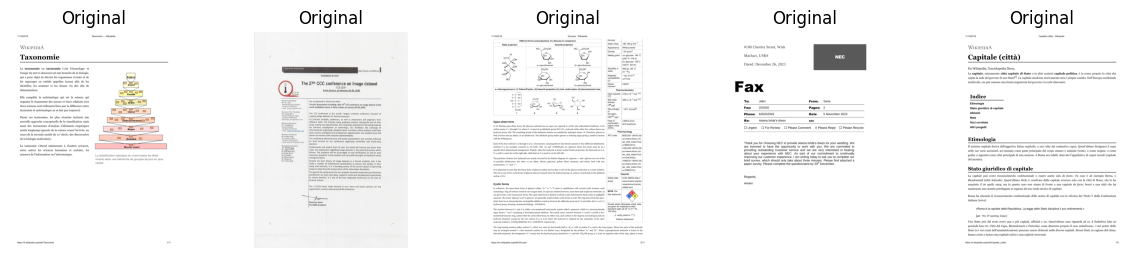

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

def get_image_paths_and_labels(original_dirs, tampered_dir, exts=(".tif", ".tiff", ".png", ".jpg", ".jpeg")):
    image_paths, labels = [], []
    for orig_dir in original_dirs:
        for fname in os.listdir(orig_dir):
            if fname.lower().endswith(exts):
                image_paths.append(os.path.join(orig_dir, fname))
                labels.append(0)
    for fname in os.listdir(tampered_dir):
        if fname.lower().endswith(exts):
            image_paths.append(os.path.join(tampered_dir, fname))
            labels.append(1)
    return image_paths, labels

def summarize_dataset(image_paths, labels):
    print(f"Total images: {len(image_paths)}")
    print(f"Class distribution: {Counter(labels)} (0=Original, 1=Tampered)")
    sizes = []
    for path in random.sample(image_paths, min(100, len(image_paths))):
        img = cv2.imread(path)
        if img is not None:
            sizes.append(img.shape)
    if sizes:
        heights = [s[0] for s in sizes]
        widths = [s[1] for s in sizes]
        print(f"Image height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.1f}")
        print(f"Image width: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.1f}")
    else:
        print("No valid images found for size summary.")

def show_sample_images(image_paths, labels, n=5):
    idxs_0 = [i for i, l in enumerate(labels) if l == 0]
    idxs_1 = [i for i, l in enumerate(labels) if l == 1]
    plt.figure(figsize=(12, 5))
    for i, idx in enumerate(random.sample(idxs_0, min(n, len(idxs_0)))):
        img = cv2.imread(image_paths[idx])
        if img is not None:
            plt.subplot(2, n, i+1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title("Original")
            plt.axis('off')
    for i, idx in enumerate(random.sample(idxs_1, min(n, len(idxs_1)))):
        img = cv2.imread(image_paths[idx])
        if img is not None:
            plt.subplot(2, n, n+i+1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title("Tampered")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

def main():
    original_dirs = ["/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs", "/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Original"]
    tampered_dir = "/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Tampered"
    image_paths, labels = get_image_paths_and_labels(original_dirs, tampered_dir)
    summarize_dataset(image_paths, labels)
    show_sample_images(image_paths, labels, n=5)

if __name__ == "__main__":
    main()

                                                                 PREPROCESSING

In [ ]:
import os
import cv2
import numpy as np


def get_image_paths_and_labels(original_dirs, tampered_dir, exts=(".tif", ".tiff", ".png", ".jpg", ".jpeg")):
    image_paths, labels = [], []

    # -----------------------
    # Process original directories
    # -----------------------
    for orig_dir in original_dirs:
        for fname in os.listdir(orig_dir):
            full_path = os.path.join(orig_dir, fname)
            if os.path.isfile(full_path) and fname.lower().endswith(exts):
                image_paths.append(full_path)
                labels.append(0)  # Original

    # -----------------------
    # Process tampered images (first-level subfolders only)
    # -----------------------
    tampered_main = os.path.join(tampered_dir, "Tampered")
    for subfolder in os.listdir(tampered_main):
        # Skip the Original folder inside TamperedImages
        if subfolder.lower() == "original":
            continue

        subfolder_path = os.path.join(tampered_main, subfolder)
        if not os.path.isdir(subfolder_path):
            continue

        # Only process files in the first-level folder, skip nested subfolders
        for fname in os.listdir(subfolder_path):
            fpath = os.path.join(subfolder_path, fname)
            if os.path.isfile(fpath) and fname.lower().endswith(exts):
                image_paths.append(fpath)
                labels.append(1)  # Tampered

    print(f"Total images: {len(image_paths)} | Original: {labels.count(0)} | Tampered: {labels.count(1)}")
    return image_paths, labels


def preprocess_and_save_images(image_paths, labels, out_dir, size=(256, 256)):
    original_dir = os.path.join(out_dir, 'original')
    tampered_dir = os.path.join(out_dir, 'tampered')
    os.makedirs(original_dir, exist_ok=True)
    os.makedirs(tampered_dir, exist_ok=True)

    count_orig, count_tamp = 0, 0

    for path, label in zip(image_paths, labels):
        # Read image with unchanged flag to retain original depth
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            print(f"⚠️  Warning: Cannot read {path}")
            continue

        # Convert 16-bit to 8-bit if needed
        if img.dtype == np.uint16:
            img = (img / 256).astype(np.uint8)

        # Convert to grayscale if image has 3 channels
        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize to fixed size 256x256
        img_resized = cv2.resize(img, size)

        # Normalize pixel values to [0,1]
        img_norm = img_resized.astype(np.float32) / 255.0

        save_subdir = original_dir if label == 0 else tampered_dir
        parent_folder = os.path.basename(os.path.dirname(path))
        base_name = os.path.splitext(os.path.basename(path))[0]
        unique_name = f"{parent_folder}_{base_name}.npy"

        np.save(os.path.join(save_subdir, unique_name), img_norm)

        if label == 0:
            count_orig += 1
        else:
            count_tamp += 1

    print(f"\n✅ Preprocessing complete!")
    print(f"Total original images processed: {count_orig}")
    print(f"Total tampered images processed: {count_tamp}")
    print(f"Saved preprocessed images as .npy in: {out_dir}")


def main():
    original_dirs = [
        "/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs",
        "/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Original"
    ]
    tampered_dir = "/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages"
    out_dir = "/content/drive/MyDrive/AI_TRACEFINDER_DS/Preprocessed_Data"

    image_paths, labels = get_image_paths_and_labels(original_dirs, tampered_dir)
    preprocess_and_save_images(image_paths, labels, out_dir, size=(256, 256))


if __name__ == "__main__":
    main()


Total images: 344 | Original: 242 | Tampered: 102

✅ Preprocessing complete!
Total original images processed: 242
Total tampered images processed: 102
Saved preprocessed images as .npy in: /content/drive/MyDrive/AI_TRACEFINDER_DS/Preprocessed_Data


In [ ]:
import os

def verify_labels(original_dirs, tampered_dir, exts=(".tif", ".tiff", ".png", ".jpg", ".jpeg")):
    image_paths, labels = [], []

    # Check original images
    for orig_dir in original_dirs:
        for fname in os.listdir(orig_dir):
            full_path = os.path.join(orig_dir, fname)
            if os.path.isfile(full_path) and fname.lower().endswith(exts):
                image_paths.append(full_path)
                labels.append(0)

    # Check tampered images (first-level subfolders only)
    tampered_main = os.path.join(tampered_dir, "Tampered")
    for subfolder in os.listdir(tampered_main):
        if subfolder.lower() == "original":
            continue  # Skip the Original folder inside TamperedImages
        subfolder_path = os.path.join(tampered_main, subfolder)
        if not os.path.isdir(subfolder_path):
            continue
        for fname in os.listdir(subfolder_path):
            fpath = os.path.join(subfolder_path, fname)
            if os.path.isfile(fpath) and fname.lower().endswith(exts):
                image_paths.append(fpath)
                labels.append(1)

    # Summary
    print(f"Total images found: {len(image_paths)}")
    print(f"Original images (label=0): {labels.count(0)}")
    print(f"Tampered images (label=1): {labels.count(1)}")

    # Optional: list a few examples
    print("\nSample Originals:", image_paths[:5])
    print("Sample Tampered:", image_paths[-5:])

    # Quick consistency check
    if len(image_paths) != labels.count(0) + labels.count(1):
        print("⚠️  Warning: Some images may be miscounted!")
    else:
        print("✅ All images appear labeled correctly.")

# Example usage
original_dirs = [
    "/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs",
    "/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Original"
]
tampered_dir = "/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages"

verify_labels(original_dirs, tampered_dir)


Total images found: 344
Original images (label=0): 242
Tampered images (label=1): 102

Sample Originals: ['/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_13_page_1.tif', '/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_6_page_1.tif', '/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_16_page_1.tif', '/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_7_page_1.tif', '/content/drive/MyDrive/AI_TRACEFINDER_DS/Original_TIFFs/official_9_page_1.tif']
Sample Tampered: ['/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Tampered/Copy-move/s1_81_b.tif', '/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Tampered/Copy-move/s11_30_b.tif', '/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Tampered/Copy-move/s11_35_b.tif', '/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Tampered/Copy-move/s11_34_b.tif', '/content/drive/MyDrive/AI_TRACEFINDER_DS/TamperedImages/Tampered/Copy-move/s11_49_b.tif']
✅ All images ap

                                                          FEATURE EXTRACTION

In [ ]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
from skimage.feature import local_binary_pattern, hog, graycomatrix, graycoprops
from scipy.fftpack import dct
import pywt

# ------------------------
# Texture Features
# ------------------------
def extract_texture_features(img, already_gray=False):
    # Assume img normalized in [0,1], convert accordingly
    if already_gray:
        gray = (img * 255).astype(np.uint8)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # LBP (fixed 10-bin histogram)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)

    # HOG → force resize to 256x256 (consistent with preprocessing)
    gray_resized = cv2.resize(gray, (256, 256))
    hog_feat = hog(
        gray_resized,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        feature_vector=True
    )

    # GLCM → fixed 6 properties with 256 levels (0-255)
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)
    glcm_props = [graycoprops(glcm, prop).ravel() for prop in
                  ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']]
    glcm_feat = np.concatenate(glcm_props)

    return np.concatenate([lbp_hist, hog_feat, glcm_feat])


# ------------------------
# Frequency Features
# ------------------------
def extract_frequency_features(img, already_gray=False):
    if already_gray:
        gray = (img * 255).astype(np.uint8)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray_resized = cv2.resize(gray, (256, 256))

    # FFT → take top-left 10x10 magnitude (100 elements)
    f = np.fft.fft2(gray_resized)
    fshift = np.fft.fftshift(f)
    fft_feat = np.abs(fshift)[:10, :10].flatten()

    # DCT → top-left 10x10
    dct_coeff = dct(dct(gray_resized.T, norm='ortho').T, norm='ortho')
    dct_feat = dct_coeff[:10, :10].flatten()

    # DWT → take first 100 coefficients from each sub-band
    coeffs = pywt.dwt2(gray_resized, 'haar')
    cA, (cH, cV, cD) = coeffs
    dwt_feat = np.concatenate([
        cA.flatten()[:100],
        cH.flatten()[:100],
        cV.flatten()[:100],
        cD.flatten()[:100]
    ])

    return np.concatenate([fft_feat, dct_feat, dwt_feat])


# ------------------------
# Noise Features
# ------------------------
def extract_noise_features(img, already_gray=False):
    if already_gray:
        gray = (img * 255).astype(np.uint8)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray_resized = cv2.resize(gray, (256, 256))

    # Residual
    denoised = cv2.medianBlur(gray_resized, 3)
    residual = gray_resized.astype(np.float32) - denoised.astype(np.float32)
    res_mean = np.mean(residual)
    res_std = np.std(residual)

    # PRNU (high-frequency noise)
    highpass = cv2.Laplacian(gray_resized, cv2.CV_64F)
    prnu_std = np.std(highpass)

    return np.array([res_mean, res_std, prnu_std])


# ------------------------
# Color Features
# ------------------------
def extract_color_features(img, already_gray=False):
    if already_gray:
        gray = (img * 255).astype(np.uint8)
        hist = cv2.calcHist([gray], [0], None, [32], [0, 256]).flatten()
        hist = hist / np.sum(hist)
        return hist
    else:
        img_resized = cv2.resize(img, (256, 256))

        # Channel statistics: means, stddevs, skews, kurtosis
        means = np.mean(img_resized, axis=(0, 1))
        stds = np.std(img_resized, axis=(0, 1))
        skews = np.array([np.mean((img_resized[..., i] - means[i]) ** 3) for i in range(3)])
        kurtosis = np.array([np.mean((img_resized[..., i] - means[i]) ** 4) for i in range(3)])

        # Grayscale histogram
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        hist = cv2.calcHist([gray], [0], None, [32], [0, 256]).flatten()
        hist = hist / np.sum(hist)

        return np.concatenate([means, stds, skews, kurtosis, hist])


# ------------------------
# Dataset Loader
# ------------------------
def load_preprocessed_images_and_labels(preproc_dir):
    X, y = [], []
    orig_dir = os.path.join(preproc_dir, 'original')
    tamp_dir = os.path.join(preproc_dir, 'tampered')

    for fname in os.listdir(orig_dir):
        if fname.endswith('.npy'):
            arr = np.load(os.path.join(orig_dir, fname))
            X.append(arr)
            y.append(0)

    for fname in os.listdir(tamp_dir):
        if fname.endswith('.npy'):
            arr = np.load(os.path.join(tamp_dir, fname))
            X.append(arr)
            y.append(1)

    return X, y


# ------------------------
# Feature Extraction Driver
# ------------------------
def extract_all_features(X):
    features = []
    for img in tqdm(X, desc="Extracting features"):
        f1 = extract_texture_features(img, already_gray=True)
        f2 = extract_frequency_features(img, already_gray=True)
        f3 = extract_noise_features(img, already_gray=True)
        f4 = extract_color_features(img, already_gray=True)
        features.append(np.concatenate([f1, f2, f3, f4]))
    return np.array(features)


def main():
    preproc_dir = "/content/drive/MyDrive/AI_TRACEFINDER_DS/Preprocessed_Data"

    # Load dataset
    X, y = load_preprocessed_images_and_labels(preproc_dir)
    print(f"Loaded {len(X)} preprocessed images.")

    # Train-val split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Feature extraction
    X_train_feat = extract_all_features(X_train)
    X_val_feat = extract_all_features(X_val)

    # Scaling
    scaler = StandardScaler()
    X_train_feat = scaler.fit_transform(X_train_feat)
    X_val_feat = scaler.transform(X_val_feat)

    # Save features + scaler
    np.savez("/content/drive/MyDrive/AI_TRACEFINDER_DS/features_all.npz", X=np.vstack([X_train_feat, X_val_feat]), y=np.hstack([y_train, y_val]))

    joblib.dump(scaler, "/content/drive/MyDrive/AI_TRACEFINDER_DS/scaler.joblib")

    print("✅ Feature extraction + scaling complete. Saved features and scaler.")


if __name__ == "__main__":
    main()


Loaded 344 preprocessed images.


Extracting features: 100%|██████████| 69/69 [00:03<00:00, 22.63it/s]


✅ Feature extraction + scaling complete. Saved features and scaler.


                                                              TRAINING

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import joblib

def find_best_threshold(y_true, y_prob, search=(0.2, 0.8, 1201)):
    lo, hi, steps = search
    ths = np.linspace(lo, hi, steps)
    best_thr, best_acc = 0.5, 0.0
    for t in ths:
        acc = accuracy_score(y_true, (y_prob >= t).astype(int))
        if acc > best_acc:
            best_acc, best_thr = acc, t
    return best_thr, best_acc

def report(name, y_true, y_pred):
    print(f"\n=== {name} Report ===")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['Original', 'Tampered']))

def main():
    # Paths
    preproc_feat_path = "/content/drive/MyDrive/AI_TRACEFINDER_DS/features_all.npz"
    scaler_path       = "/content/drive/MyDrive/AI_TRACEFINDER_DS/scaler.joblib"
    model_out_path    = "/content/drive/MyDrive/AI_TRACEFINDER_DS/best_nn_ensemble_smote_threshold.joblib"

    # Load data
    data = np.load(preproc_feat_path, allow_pickle=True)
    X, y = data['X'], data['y']
    print(f"✅ Loaded feature set: {X.shape}, labels: {len(y)}")

    # Scale
    scaler = joblib.load(scaler_path)
    X = scaler.transform(X)
    print("✅ Features scaled using saved scaler")

    # Split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )
    print(f"➡️ Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # Ensemble settings
    seeds = [11, 22, 33, 44, 55]
    models = []
    val_probs_list = []
    test_probs_list = []

    print("\n==================================================")
    print("Training MLP Ensemble (No PCA) + SMOTE + Threshold Tuning")
    print("==================================================")

    for i, seed in enumerate(seeds, 1):
        # SMOTE per model (diversify with different random_state)
        sm = SMOTE(random_state=seed, k_neighbors=5)
        X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
        print(f"✅ SMOTE[{i}] applied: {X_train.shape} -> {X_train_bal.shape}")

        # MLP config
        clf = MLPClassifier(
            hidden_layer_sizes=(512, 256, 128),
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate='adaptive',
            learning_rate_init=5e-4,
            max_iter=2500,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=25,
            random_state=seed
        )

        clf.fit(X_train_bal, y_train_bal)
        models.append(clf)

        # Collect probabilities
        val_probs  = clf.predict_proba(X_val)[:, 1]
        test_probs = clf.predict_proba(X_test)[:, 1]
        val_probs_list.append(val_probs)
        test_probs_list.append(test_probs)

        # Quick per-model log
        print(f"Model {i}: Val Acc={clf.score(X_val, y_val):.4f} | Test Acc={clf.score(X_test, y_test):.4f}")

    # Average probabilities across the ensemble
    val_probs_ens  = np.mean(val_probs_list, axis=0)
    test_probs_ens = np.mean(test_probs_list, axis=0)

    # Threshold tuning on validation (ensemble probs)
    best_thr, best_val_acc = find_best_threshold(y_val, val_probs_ens, search=(0.2, 0.8, 1201))
    print(f"\n✅ Ensemble best threshold on Val: {best_thr:.3f} (Val Acc: {best_val_acc:.4f})")

    # Evaluate with tuned threshold
    y_val_pred_t  = (val_probs_ens  >= best_thr).astype(int)
    y_test_pred_t = (test_probs_ens >= best_thr).astype(int)

    val_acc_t  = accuracy_score(y_val,  y_val_pred_t)
    test_acc_t = accuracy_score(y_test, y_test_pred_t)

    print(f"\n=== Ensemble Tuned-Threshold Results ({best_thr:.3f}) ===")
    print(f"Validation Accuracy:  {val_acc_t:.4f}")
    print(f"Test Accuracy:        {test_acc_t:.4f}")

    report("Validation (Ensemble tuned thr)", y_val,  y_val_pred_t)
    report("Test (Ensemble tuned thr)",      y_test, y_test_pred_t)

    # Save bundle (scaler, models list, threshold)
    bundle = {
        "scaler": scaler,
        "models": models,
        "threshold": best_thr,
        "seeds": seeds
    }
    joblib.dump(bundle, model_out_path)
    print(f"\n✅ Saved ensemble+threshold to: {model_out_path}")

if __name__ == "__main__":
    main()

✅ Loaded feature set: (344, 8751), labels: 344
✅ Features scaled using saved scaler
➡️ Train: (240, 8751), Val: (52, 8751), Test: (52, 8751)

Training MLP Ensemble (No PCA) + SMOTE + Threshold Tuning
✅ SMOTE[1] applied: (240, 8751) -> (338, 8751)
Model 1: Val Acc=0.8077 | Test Acc=0.8654
✅ SMOTE[2] applied: (240, 8751) -> (338, 8751)
Model 2: Val Acc=0.8462 | Test Acc=0.9231
✅ SMOTE[3] applied: (240, 8751) -> (338, 8751)
Model 3: Val Acc=0.8269 | Test Acc=0.9038
✅ SMOTE[4] applied: (240, 8751) -> (338, 8751)
Model 4: Val Acc=0.7885 | Test Acc=0.8462
✅ SMOTE[5] applied: (240, 8751) -> (338, 8751)
Model 5: Val Acc=0.8462 | Test Acc=0.9231

✅ Ensemble best threshold on Val: 0.200 (Val Acc: 0.8462)

=== Ensemble Tuned-Threshold Results (0.200) ===
Validation Accuracy:  0.8462
Test Accuracy:        0.9231

=== Validation (Ensemble tuned thr) Report ===
[[28  8]
 [ 0 16]]
              precision    recall  f1-score   support

    Original       1.00      0.78      0.88        36
    Tampered

In [ ]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

# -----------------------
# Utilities
# -----------------------
def sweep_best_threshold(y_true, y_prob, lo=0.2, hi=0.8, steps=1201, maximize="accuracy"):
    ths = np.linspace(lo, hi, steps)
    best_thr, best_score = 0.5, -1.0
    for t in ths:
        y_pred = (y_prob >= t).astype(int)
        if maximize == "accuracy":
            score = accuracy_score(y_true, y_pred)
        elif maximize == "tampered_precision":
            # minimize false positives on Original by maximizing precision for Tampered
            tp = np.sum((y_true == 1) & (y_pred == 1))
            fp = np.sum((y_true == 0) & (y_pred == 1))
            score = tp / (tp + fp + 1e-9)
        else:
            score = accuracy_score(y_true, y_pred)
        if score > best_score:
            best_score, best_thr = score, t
    return best_thr, best_score

def report(name, y_true, y_pred):
    print(f"\n=== {name} Report ===")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['Original', 'Tampered']))

def probs_to_metrics(label, y_true, y_prob):
    try:
        roc = roc_auc_score(y_true, y_prob)
    except Exception:
        roc = float('nan')
    try:
        pr  = average_precision_score(y_true, y_prob)
    except Exception:
        pr  = float('nan')
    print(f"{label} ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")
    return roc, pr

# -----------------------
# Cross-validation (robustness check)
# -----------------------
def cv_robustness_check(X, y, seeds=(11, 22, 33), n_splits=5, n_repeats=5):
    # For efficiency, use a single-MLP model per fold (with SMOTE inside each fold) and average across seeds
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
    accs, rocs, prs = [], [], []
    for fold_idx, (train_idx, val_idx) in enumerate(rskf.split(X, y), 1):
        X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]

        val_probs_seed = []
        for seed in seeds:
            sm = SMOTE(random_state=seed, k_neighbors=5)
            X_bal, y_bal = sm.fit_resample(X_tr, y_tr)

            clf = MLPClassifier(
                hidden_layer_sizes=(512, 256, 128),
                activation='relu',
                solver='adam',
                alpha=1e-4,
                learning_rate='adaptive',
                learning_rate_init=5e-4,
                max_iter=2500,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=25,
                random_state=seed
            )
            clf.fit(X_bal, y_bal)
            val_probs_seed.append(clf.predict_proba(X_va)[:, 1])

        val_probs_mean = np.mean(val_probs_seed, axis=0)
        y_val_pred_default = (val_probs_mean >= 0.5).astype(int)
        accs.append(accuracy_score(y_va, y_val_pred_default))
        try:
            rocs.append(roc_auc_score(y_va, val_probs_mean))
            prs.append(average_precision_score(y_va, val_probs_mean))
        except Exception:
            pass

    accs = np.asarray(accs)
    rocs = np.asarray(rocs) if len(rocs) else np.array([np.nan])
    prs  = np.asarray(prs)  if len(prs)  else np.array([np.nan])
    print("\n=== Cross-Validation Robustness (Repeated Stratified 5x5) ===")
    print(f"CV Accuracy: mean={accs.mean():.4f} std={accs.std():.4f} (n={len(accs)})")
    print(f"CV ROC-AUC:  mean={np.nanmean(rocs):.4f} std={np.nanstd(rocs):.4f}")
    print(f"CV PR-AUC:   mean={np.nanmean(prs):.4f} std={np.nanstd(prs):.4f}")

# -----------------------
# Main Training with Ensemble, Calibration, Thresholds
# -----------------------
def main():
    # Paths
    preproc_feat_path = "/content/drive/MyDrive/AI_TRACEFINDER_DS/features_all.npz"
    scaler_path       = "/content/drive/MyDrive/AI_TRACEFINDER_DS/scaler.joblib"
    model_out_path    = "/content/drive/MyDrive/AI_TRACEFINDER_DS/best_nn_ensemble_smote_threshold_calibrated.joblib"

    # Load data
    data = np.load(preproc_feat_path, allow_pickle=True)
    X, y = data['X'], data['y']
    print(f"✅ Loaded feature set: {X.shape}, labels: {len(y)}")

    # Scale
    scaler = joblib.load(scaler_path)
    X = scaler.transform(X)
    print("✅ Features scaled using saved scaler")

    # Split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )
    print(f"➡️ Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # Cross-validation robustness
    cv_robustness_check(X, y, seeds=(11, 22, 33), n_splits=5, n_repeats=5)

    # Ensemble settings (adjust 3–7 seeds for compute/perf tradeoff)
    seeds = [11, 22, 33, 44, 55]
    models = []
    val_probs_list = []
    test_probs_list = []

    print("\n==================================================")
    print("Training MLP Ensemble (No PCA) + SMOTE + Calibration + Threshold Tuning")
    print("==================================================")

    for i, seed in enumerate(seeds, 1):
        sm = SMOTE(random_state=seed, k_neighbors=5)
        X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
        print(f"✅ SMOTE[{i}] applied: {X_train.shape} -> {X_train_bal.shape}")

        clf = MLPClassifier(
            hidden_layer_sizes=(512, 256, 128),
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate='adaptive',
            learning_rate_init=5e-4,
            max_iter=2500,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=25,
            random_state=seed
        )
        clf.fit(X_train_bal, y_train_bal)
        models.append(clf)

        val_probs  = clf.predict_proba(X_val)[:, 1]
        test_probs = clf.predict_proba(X_test)[:, 1]
        val_probs_list.append(val_probs)
        test_probs_list.append(test_probs)

        print(f"Model {i}: Val Acc={clf.score(X_val, y_val):.4f} | Test Acc={clf.score(X_test, y_test):.4f}")

    # Average probs
    val_probs_ens  = np.mean(val_probs_list, axis=0)
    test_probs_ens = np.mean(test_probs_list, axis=0)

    # Calibration on validation predictions (isotonic regression)
    iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
    iso.fit(val_probs_ens, y_val)
    val_probs_cal  = iso.transform(val_probs_ens)
    test_probs_cal = iso.transform(test_probs_ens)
    print("\nCalibration: Isotonic regression fitted on validation ensemble probabilities.")

    # Metrics (ROC/PR) before/after calibration
    print("\n=== Probabilistic Metrics (Ensemble) ===")
    probs_to_metrics("VAL  (uncalibrated)", y_val,  val_probs_ens)
    probs_to_metrics("TEST (uncalibrated)", y_test, test_probs_ens)
    probs_to_metrics("VAL  (calibrated)  ", y_val,  val_probs_cal)
    probs_to_metrics("TEST (calibrated)  ", y_test, test_probs_cal)

    # Threshold 1: maximize validation accuracy in broad range
    best_thr_acc, best_val_acc = sweep_best_threshold(y_val, val_probs_cal, lo=0.2, hi=0.8, steps=1201, maximize="accuracy")
    print(f"\n✅ Best threshold (maximize Val accuracy): {best_thr_acc:.3f} (Val Acc: {best_val_acc:.4f})")

    # Threshold 2: minimize false positives by prioritizing Tampered precision in a narrower range
    best_thr_prec, best_val_prec = sweep_best_threshold(y_val, val_probs_cal, lo=0.25, hi=0.35, steps=401, maximize="tampered_precision")
    print(f"✅ Best threshold (favor fewer FPs, 0.25–0.35 window): {best_thr_prec:.3f} (Val Tampered-precision proxy: {best_val_prec:.4f})")

    # Evaluate both thresholds on validation and test
    def eval_at_thr(tag, thr, probs_val, probs_test):
        yv = (probs_val  >= thr).astype(int)
        yt = (probs_test >= thr).astype(int)
        va = accuracy_score(y_val,  yv)
        ta = accuracy_score(y_test, yt)
        print(f"\n=== {tag} (thr={thr:.3f}) ===")
        print(f"Validation Accuracy:  {va:.4f}")
        print(f"Test Accuracy:        {ta:.4f}")
        report(f"Validation {tag}", y_val,  yv)
        report(f"Test {tag}",      y_test, yt)
        return va, ta, yv, yt

    val_acc_a, test_acc_a, yv_a, yt_a = eval_at_thr("Max-Accuracy", best_thr_acc,  val_probs_cal, test_probs_cal)
    val_acc_b, test_acc_b, yv_b, yt_b = eval_at_thr("Low-FP Window", best_thr_prec, val_probs_cal, test_probs_cal)

    # Pick final threshold: choose the low-FP one if test acc within 0.5% of max-accuracy; else choose max-accuracy
    final_thr = best_thr_prec if (test_acc_b >= test_acc_a - 0.005) else best_thr_acc
    print(f"\n🎯 Selected final threshold: {final_thr:.3f}")

    # Save everything for inference
    bundle = {
        "scaler": scaler,
        "models": models,
        "calibration": {
            "type": "isotonic",
            "model": iso
        },
        "threshold": final_thr,
        "seeds": seeds
    }
    joblib.dump(bundle, model_out_path)
    print(f"\n✅ Saved ensemble+calibration+threshold to: {model_out_path}")
    print("Note: At inference, compute mean prob across models, apply isotonic calibration, then compare to stored threshold.")

if __name__ == "__main__":
    main()

✅ Loaded feature set: (344, 8751), labels: 344
✅ Features scaled using saved scaler
➡️ Train: (240, 8751), Val: (52, 8751), Test: (52, 8751)

=== Cross-Validation Robustness (Repeated Stratified 5x5) ===
CV Accuracy: mean=0.8837 std=0.0281 (n=25)
CV ROC-AUC:  mean=0.8866 std=0.0305
CV PR-AUC:   mean=0.6238 std=0.0644

Training MLP Ensemble (No PCA) + SMOTE + Calibration + Threshold Tuning
✅ SMOTE[1] applied: (240, 8751) -> (338, 8751)
Model 1: Val Acc=0.8077 | Test Acc=0.8654
✅ SMOTE[2] applied: (240, 8751) -> (338, 8751)
Model 2: Val Acc=0.8462 | Test Acc=0.9231
✅ SMOTE[3] applied: (240, 8751) -> (338, 8751)
Model 3: Val Acc=0.8269 | Test Acc=0.9038
✅ SMOTE[4] applied: (240, 8751) -> (338, 8751)
Model 4: Val Acc=0.7885 | Test Acc=0.8462
✅ SMOTE[5] applied: (240, 8751) -> (338, 8751)
Model 5: Val Acc=0.8462 | Test Acc=0.9231

Calibration: Isotonic regression fitted on validation ensemble probabilities.

=== Probabilistic Metrics (Ensemble) ===
VAL  (uncalibrated) ROC-AUC: 0.8307 | PR-A

                                                                   TESTING

In [ ]:
import os
import glob
import csv
import joblib
import numpy as np
import cv2

from skimage.feature import local_binary_pattern, hog, graycomatrix, graycoprops
from scipy.fftpack import dct
import pywt

# =========================
# CONFIG: set your paths here
# =========================
BUNDLE_PATH = "/content/drive/MyDrive/AI_TRACEFINDER_DS/best_nn_ensemble_smote_threshold_calibrated.joblib"
INPUTS = [
    "/content/drive/MyDrive/AI_TRACEFINDER_DS/Official/Canon120-2/300/s2_3.tif",
    "/content/drive/MyDrive/AI_TRACEFINDER_DS/test_images",          # directory (recursive)
    "/content/drive/MyDrive/AI_TRACEFINDER_DS/Wikipedia/HP/150/s11_2.tif"  # single file
]
OUT_CSV = "/content/drive/MyDrive/AI_TRACEFINDER_DS/predictions.csv"  # or None to skip saving

# Calibration/threshold controls
USE_CALIBRATION = False   # False = use raw ensemble prob
THRESHOLD = 0.30          # try 0.30–0.35 to reduce false positives

# Optional threshold sweep diagnostics
DO_THRESHOLD_SWEEP = True
TEST_THRESHOLDS = [0.25, 0.30, 0.35, 0.40, 0.45]

ORIGINAL = 0
TAMPERED = 1
LABELS = {0: "Original", 1: "Tampered"}
VALID_EXTS = (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp")

# ------------------------
# Image preprocessing (match your training preprocessing)
# ------------------------
def preprocess_image_for_features(image_path, size=(256, 256)):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    if img.dtype == np.uint16:
        img = (img / 256).astype(np.uint8)
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, size)
    img_norm = img_resized.astype(np.float32) / 255.0
    return img_norm

# ------------------------
# Feature extraction (same as training)
# ------------------------
def extract_texture_features(img, already_gray=False):
    if already_gray:
        gray = (img * 255).astype(np.uint8)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)
    gray_resized = cv2.resize(gray, (256, 256))
    hog_feat = hog(gray_resized, pixels_per_cell=(16, 16), cells_per_block=(2, 2), feature_vector=True)
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)
    glcm_props = [graycoprops(glcm, prop).ravel() for prop in
                  ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']]
    glcm_feat = np.concatenate(glcm_props)
    return np.concatenate([lbp_hist, hog_feat, glcm_feat])

def extract_frequency_features(img, already_gray=False):
    if already_gray:
        gray = (img * 255).astype(np.uint8)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_resized = cv2.resize(gray, (256, 256))
    f = np.fft.fft2(gray_resized)
    fshift = np.fft.fftshift(f)
    fft_feat = np.abs(fshift)[:10, :10].flatten()
    dct_coeff = dct(dct(gray_resized.T, norm='ortho').T, norm='ortho')
    dct_feat = dct_coeff[:10, :10].flatten()
    coeffs = pywt.dwt2(gray_resized, 'haar')
    cA, (cH, cV, cD) = coeffs
    dwt_feat = np.concatenate([
        cA.flatten()[:100],
        cH.flatten()[:100],
        cV.flatten()[:100],
        cD.flatten()[:100]
    ])
    return np.concatenate([fft_feat, dct_feat, dwt_feat])

def extract_noise_features(img, already_gray=False):
    if already_gray:
        gray = (img * 255).astype(np.uint8)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_resized = cv2.resize(gray, (256, 256))
    denoised = cv2.medianBlur(gray_resized, 3)
    residual = gray_resized.astype(np.float32) - denoised.astype(np.float32)
    res_mean = np.mean(residual)
    res_std = np.std(residual)
    highpass = cv2.Laplacian(gray_resized, cv2.CV_64F)
    prnu_std = np.std(highpass)
    return np.array([res_mean, res_std, prnu_std])

def extract_color_features(img, already_gray=False):
    if already_gray:
        gray = (img * 255).astype(np.uint8)
        hist = cv2.calcHist([gray], [0], None, [32], [0, 256]).flatten()
        hist = hist / np.sum(hist)
        return hist
    else:
        img_resized = cv2.resize(img, (256, 256))
        means = np.mean(img_resized, axis=(0, 1))
        stds = np.std(img_resized, axis=(0, 1))
        skews = np.array([np.mean((img_resized[..., i] - means[i]) ** 3) for i in range(3)])
        kurtosis = np.array([np.mean((img_resized[..., i] - means[i]) ** 4) for i in range(3)])
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        hist = cv2.calcHist([gray], [0], None, [32], [0, 256]).flatten()
        hist = hist / np.sum(hist)
        return np.concatenate([means, stds, skews, kurtosis, hist])

def extract_features_from_image(image_path):
    img_norm_gray = preprocess_image_for_features(image_path, size=(256, 256))
    f1 = extract_texture_features(img_norm_gray, already_gray=True)
    f2 = extract_frequency_features(img_norm_gray, already_gray=True)
    f3 = extract_noise_features(img_norm_gray, already_gray=True)
    f4 = extract_color_features(img_norm_gray, already_gray=True)
    feats = np.concatenate([f1, f2, f3, f4]).astype(np.float32)
    return feats  # (8751,)

# ------------------------
# Inference utils
# ------------------------
def load_bundle(bundle_path):
    bundle = joblib.load(bundle_path)
    scaler = bundle["scaler"]
    models = bundle["models"]
    iso = bundle.get("calibration", {}).get("model", None)
    threshold = bundle["threshold"]
    return scaler, models, iso, threshold

def ensure_2d(X):
    X = np.asarray(X)
    return X.reshape(1, -1) if X.ndim == 1 else X

def ensemble_mean_proba(models, X_scaled):
    probs = [m.predict_proba(X_scaled)[:, 1] for m in models]
    return np.mean(np.stack(probs, axis=0), axis=0)

def calibrated_proba(probs, iso):
    return probs if iso is None else iso.transform(probs)

# return raw and used (calibrated or raw) probs
def predict_label_from_features(feats, scaler, models, iso, threshold, use_calibration=True):
    X = ensure_2d(feats)
    Xs = scaler.transform(X)
    p_raw = ensemble_mean_proba(models, Xs)
    p_used = calibrated_proba(p_raw, iso) if (iso is not None and use_calibration) else p_raw
    y = (p_used >= threshold).astype(int)
    return int(y[0]), float(p_raw[0]), float(p_used[0])

# ------------------------
# Batch helpers
# ------------------------
def collect_image_paths(inputs):
    paths = []
    for inp in inputs:
        if os.path.isdir(inp):
            for root, _, files in os.walk(inp):
                for f in files:
                    if f.lower().endswith(VALID_EXTS):
                        paths.append(os.path.join(root, f))
        else:
            if any(ch in inp for ch in ["*", "?", "["]):
                paths.extend([p for p in glob.glob(inp, recursive=True) if p.lower().endswith(VALID_EXTS)])
            elif os.path.isfile(inp) and inp.lower().endswith(VALID_EXTS):
                paths.append(inp)
    seen, uniq = set(), []
    for p in paths:
        if p not in seen:
            uniq.append(p); seen.add(p)
    return uniq

# ------------------------
# Main (hardcoded paths)
# ------------------------
def main():
    scaler, models, iso, saved_thr = load_bundle(BUNDLE_PATH)
    threshold = THRESHOLD

    img_paths = collect_image_paths(INPUTS)
    if not img_paths:
        print("No images found. Check INPUTS in the script.")
        return

    print(f"Found {len(img_paths)} images. Predicting...")

    # Optional: threshold sweep diagnostics (calibration OFF)
    if DO_THRESHOLD_SWEEP and TEST_THRESHOLDS:
        print("\n=== Threshold sweep (calibration OFF) ===")
        for thr in TEST_THRESHOLDS:
            print(f"\n=== Threshold {thr:.2f} ===")
            for p in img_paths:
                try:
                    feats = extract_features_from_image(p)
                    _, _, prob_used = predict_label_from_features(
                        feats, scaler, models, iso, thr, use_calibration=False
                    )
                    pred = 1 if prob_used >= thr else 0
                    print(f"{os.path.basename(p)} -> {LABELS[pred]} | prob={prob_used:.4f}")
                except Exception as e:
                    print(f"{os.path.basename(p)} -> ERROR: {e}")

    rows = []
    for p in img_paths:
        try:
            feats = extract_features_from_image(p)
            yhat, prob_raw, prob_used = predict_label_from_features(
                feats, scaler, models, iso, threshold, use_calibration=USE_CALIBRATION
            )
            label = LABELS[yhat]
            print(f"{p} -> {label} | prob_raw={prob_raw:.4f} | prob_used={prob_used:.4f} | thr={threshold:.3f} | cal={'on' if USE_CALIBRATION else 'off'}")
            rows.append([p, yhat, label, prob_raw, prob_used, threshold, 'on' if USE_CALIBRATION else 'off'])
        except Exception as e:
            print(f"{p} -> ERROR: {e}")
            rows.append([p, -1, "ERROR", np.nan, np.nan, threshold, 'on' if USE_CALIBRATION else 'off'])

    if OUT_CSV:
        os.makedirs(os.path.dirname(OUT_CSV) or ".", exist_ok=True)
        with open(OUT_CSV, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["image_path", "pred_label", "pred_name", "prob_raw", "prob_used", "threshold", "calibration"])
            w.writerows(rows)
        print(f"Saved results to {OUT_CSV}")

if __name__ == "__main__":
    main()

Found 12 images. Predicting...

=== Threshold sweep (calibration OFF) ===

=== Threshold 0.25 ===
s2_3.tif -> Original | prob=0.0518
wikipedia_107_page_1.tif -> Original | prob=0.0100
wikipedia_101_page_1.tif -> Original | prob=0.2393
official_87_page_1.tif -> Original | prob=0.0006
official_76_page_1.tif -> Original | prob=0.0013
s9_68.tif -> Tampered | prob=0.9962
s9_59.tif -> Tampered | prob=0.9440
s11_29.tif -> Tampered | prob=0.9943
s11_41_a.tif -> Tampered | prob=0.9800
s11_36_a.tif -> Tampered | prob=0.9490
s11_41_b.tif -> Tampered | prob=0.9799
s11_2.tif -> Tampered | prob=0.9264

=== Threshold 0.30 ===
s2_3.tif -> Original | prob=0.0518
wikipedia_107_page_1.tif -> Original | prob=0.0100
wikipedia_101_page_1.tif -> Original | prob=0.2393
official_87_page_1.tif -> Original | prob=0.0006
official_76_page_1.tif -> Original | prob=0.0013
s9_68.tif -> Tampered | prob=0.9962
s9_59.tif -> Tampered | prob=0.9440
s11_29.tif -> Tampered | prob=0.9943
s11_41_a.tif -> Tampered | prob=0.980

In [ ]:

import cv2
import numpy as np
import joblib
import os
import pandas as pd
from skimage.feature import local_binary_pattern, hog, graycomatrix, graycoprops
from scipy.fftpack import dct
import pywt

# ------------------------
# Feature Extraction Utils
# ------------------------
def extract_texture_features(img):
    gray = (img * 255).astype(np.uint8)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)
    gray_resized = cv2.resize(gray, (256, 256))
    hog_feat = hog(gray_resized, pixels_per_cell=(16,16), cells_per_block=(2,2), feature_vector=True)
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)
    glcm_props = [graycoprops(glcm, prop).ravel() for prop in
                  ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']]
    glcm_feat = np.concatenate(glcm_props)
    return np.concatenate([lbp_hist, hog_feat, glcm_feat])

def extract_frequency_features(img):
    gray = (img * 255).astype(np.uint8)
    gray_resized = cv2.resize(gray, (256,256))
    f = np.fft.fft2(gray_resized)
    fshift = np.fft.fftshift(f)
    fft_feat = np.abs(fshift)[:10,:10].flatten()
    dct_coeff = dct(dct(gray_resized.T, norm='ortho').T, norm='ortho')
    dct_feat = dct_coeff[:10,:10].flatten()
    coeffs = pywt.dwt2(gray_resized,'haar')
    cA, (cH, cV, cD) = coeffs
    dwt_feat = np.concatenate([cA.flatten()[:100], cH.flatten()[:100], cV.flatten()[:100], cD.flatten()[:100]])
    return np.concatenate([fft_feat, dct_feat, dwt_feat])

def extract_noise_features(img):
    gray = (img * 255).astype(np.uint8)
    gray_resized = cv2.resize(gray,(256,256))
    denoised = cv2.medianBlur(gray_resized,3)
    residual = gray_resized.astype(np.float32)-denoised.astype(np.float32)
    res_mean, res_std = np.mean(residual), np.std(residual)
    highpass = cv2.Laplacian(gray_resized, cv2.CV_64F)
    prnu_std = np.std(highpass)
    return np.array([res_mean, res_std, prnu_std])

def extract_color_features(img):
    gray = (img * 255).astype(np.uint8)
    hist = cv2.calcHist([gray],[0],None,[32],[0,256]).flatten()
    hist = hist/np.sum(hist)
    return hist

def extract_all_features(img_norm):
    f1 = extract_texture_features(img_norm)
    f2 = extract_frequency_features(img_norm)
    f3 = extract_noise_features(img_norm)
    f4 = extract_color_features(img_norm)
    return np.concatenate([f1,f2,f3,f4])

# ------------------------
# Predict single image
# ------------------------
def predict_image(img_norm, bundle):
    features = extract_all_features(img_norm).reshape(1,-1)
    features = bundle["scaler"].transform(features)
    probs = [clf.predict_proba(features)[:,1] for clf in bundle["models"]]
    avg_prob = np.mean(probs,axis=0)[0]
    pred = 1 if avg_prob >= bundle["threshold"] else 0
    label = "Tampered" if pred==1 else "Original"
    return label, float(avg_prob)

# ------------------------
# Batch inference
# ------------------------
def batch_predict(image_folder, bundle, output_csv="predictions.csv"):
    results = []
    exts = (".png",".jpg",".jpeg",".tif",".tiff")
    for fname in os.listdir(image_folder):
        if not fname.lower().endswith(exts):
            continue
        img_path = os.path.join(image_folder,fname)
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if img is None:
            print(f"⚠️ Cannot read {img_path}, skipping")
            continue
        if img.dtype == np.uint16:
            img = (img/256).astype(np.uint8)
        if img.ndim==3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_resized = cv2.resize(img,(256,256))
        img_norm = img_resized.astype(np.float32)/255.0
        label, prob = predict_image(img_norm,bundle)
        results.append([fname,label,prob])
        print(f"{fname}: {label} | Tampered probability={prob:.4f}")

    df = pd.DataFrame(results,columns=["filename","prediction","tampered_prob"])
    df.to_csv(output_csv,index=False)
    print(f"\n✅ Batch predictions saved to {output_csv}")

# ------------------------
# Main
# ------------------------
if __name__=="__main__":
    model_bundle_path = "/content/drive/MyDrive/AI_TRACEFINDER_DS/best_nn_ensemble_smote_threshold.joblib"
    test_folder = "/content/drive/MyDrive/AI_TRACEFINDER_DS/test_images"  # folder with new images

    bundle = joblib.load(model_bundle_path)
    print("✅ Loaded model bundle")

    batch_predict(test_folder,bundle,output_csv="batch_predictions.csv")



✅ Loaded model bundle
wikipedia_107_page_1.tif: Original | Tampered probability=0.0100
wikipedia_101_page_1.tif: Tampered | Tampered probability=0.2393
official_87_page_1.tif: Original | Tampered probability=0.0006
official_76_page_1.tif: Original | Tampered probability=0.0013
s9_68.tif: Tampered | Tampered probability=0.9962
s9_59.tif: Tampered | Tampered probability=0.9440
s11_29.tif: Tampered | Tampered probability=0.9943
s11_41_a.tif: Tampered | Tampered probability=0.9800
s11_36_a.tif: Tampered | Tampered probability=0.9490
s11_41_b.tif: Tampered | Tampered probability=0.9799

✅ Batch predictions saved to batch_predictions.csv
